### GLM不能处理因变量分布是正态分布的情况,普通线性模型是

GLM 要求响应变量 $$Y$$ 的分布属于指数族分布，其一般形式如下：
$$f_Y(y;\theta,\phi) = \exp\left( \frac{y\theta - b(\theta)}{\phi} + c(y,\phi) \right)$$

GLM 模型结构：
$$g(\mathbb{E}[Y]) = \mathbf{x}^T \boldsymbol{\beta}$$

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
sns.set_palette("Set1")

# 读取数据
df = pd.read_csv('4.csv')

In [29]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [30]:
df_encoded = pd.get_dummies(df, drop_first=True)  # 删除第一个类别对应的列
X = df_encoded.drop("charges", axis=1)
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False


In [31]:
y = df_encoded["charges"]
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
X_train_const = sm.add_constant(X_train_scaled)
# GLM+Gamma分布+log链接函数
glm_gamma = sm.GLM(y_train, X_train_const, family=sm.families.Gamma(sm.families.links.Log()))
result = glm_gamma.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                charges   No. Observations:                 1070
Model:                            GLM   Df Residuals:                     1061
Model Family:                   Gamma   Df Model:                            8
Link Function:                    Log   Scale:                         0.45918
Method:                          IRLS   Log-Likelihood:                -10658.
Date:                Tue, 07 Jul 2026   Deviance:                       274.49
Time:                        12:55:16   Pearson chi2:                     487.
No. Iterations:                    18   Pseudo R-squ. (CS):             0.6741
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.2416      0.021    446.117      0.0

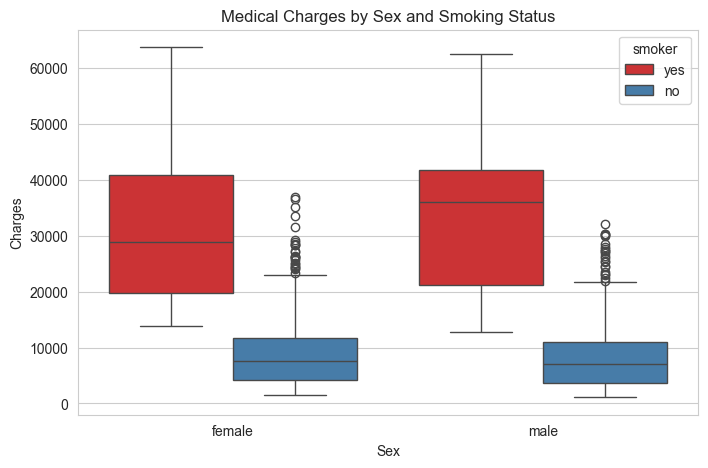

In [35]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="sex", y="charges", hue="smoker")
plt.title("Medical Charges by Sex and Smoking Status")
plt.ylabel("Charges")
plt.xlabel("Sex")
plt.show()

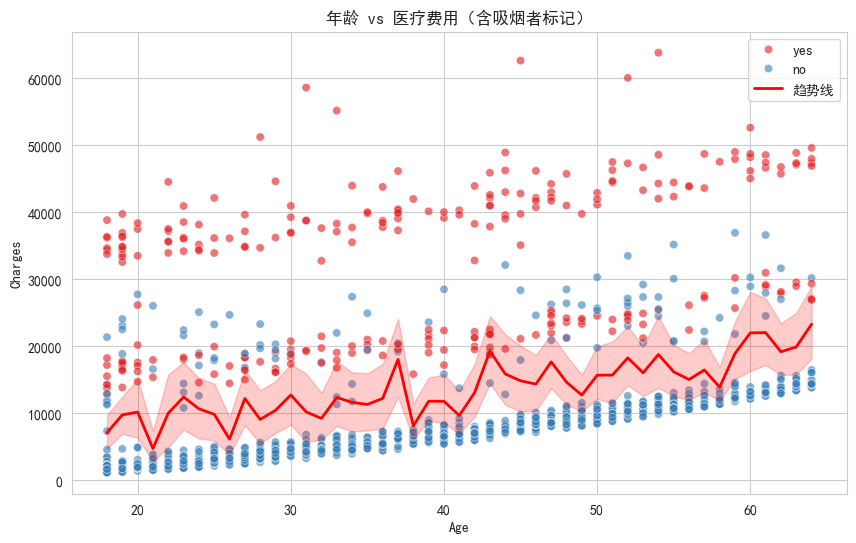

In [37]:
# 中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.6)
sns.lineplot(data=df, x="age", y="charges", color="red", label="趋势线", linewidth=2)
plt.title("年龄 vs 医疗费用（含吸烟者标记）")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.legend()
plt.show()